# Squeezing in step-index fiber

This example illustrates squeezing by spectral filtering for an LP01 launch in step-index fiber. This notebook illustrates the forward solve, adjoint, and CP compression aspects of the code.

In [1]:
using Pkg

ROOT = abspath(joinpath(@__DIR__, ".."))
Pkg.activate(ROOT)

using PulsePropagation
using FFTW
using LinearAlgebra
using PyPlot
using Statistics

  Activating project at `~/Desktop/FastDifferentiableMMNLO`


A typical flow is shown below. We start by establishing what the degrees of freedom are and setup a time-grid. We also compute the frequency and wavelength grids, which are useful to have.

In [2]:
c_light = 2.99792458e-4; # m/ps -- see manual for unit system info
Nt = 2^11;
time_window = 10; # ps
λ0 = 1379.2e-9; # m
ω0 = 2*π*c_light/λ0;

time_grid = TimeGrid(Nt,time_window);
t = time_axis(time_grid);
Ω = frequency_axis(time_grid); # constructs relative frequency
ω = ω0 .+ Ω; # absolute frequency;
λ = wavelength_axis(time_grid,ω0); # wavelength

dofs = degrees_of_freedom(:time, :space)
domain = MMGNLSEDomain(dofs, time_grid);


Now, we need to setup the dispersion and nonlinearity which determine our dynamics. This is done below by establishing the material and fiber system and computing derived properties.

In [3]:
core_radius = 52.5e-6;
NA = 0.1;
num_modes = 3;
fiber_length = 2.86;

material = Silica() # The default Silica picks an anisotropic Raman model. See other notebooks such as soliton_jitter for other Raman models;
step_fiber = StepIndex(λ0, core_radius, NA);

properties = compute_fiber_properties(step_fiber, material, num_modes, polarization=:scalar, mode_basis=:LP, beta_order=5)

FiberProperties{TaylorBeta{Float64, 2}, SpatialOverlap{Float64}, AnisotropicRaman{Float64}, FiberModeData{Float64, Float64, Vector{NamedTuple}}, @NamedTuple{profile::Symbol, material::Symbol, lambda0::Float64, core_radius::Float64, NA::Float64, num_modes::Int64, polarization::Symbol, mode_basis::Symbol, beta_order::Int64, dispersion_span::Float64, dispersion_samples::Int64, dispersion_fit_order::Int64, overlap::@NamedTuple{representation::Symbol, quadrature_order::Int64, chunk_points::Int64, max_workspace_bytes::Int64, precision::Symbol, max_tensor_bytes::Nothing}, wavelength_rule::Symbol, grid::@NamedTuple{nx::Int64, ny::Int64, xmin::Float64, xmax::Float64, ymin::Float64, ymax::Float64}}, Float64}(TaylorBeta{Float64, 2}([6.58743778344516e6 6.58721209206506e6 6.58721209206506e6; 4876.066183290184 4876.219784144979 4876.219784144979; … ; -2.557747949166768e-7 -2.569478135168283e-7 -2.569478135168283e-7; 1.0507874940407848e-9 1.0537998629535228e-9 1.0537998629535228e-9]), SpatialOverlap{

Some examples of how you can get property values from properties.

In [4]:
x = y = properties.modes.x
modes = properties.modes.fields; 
betas = properties.beta.coefficients;
S_tensor = properties.S.values;

Taking a peek at the first 3 step-index mode fields.

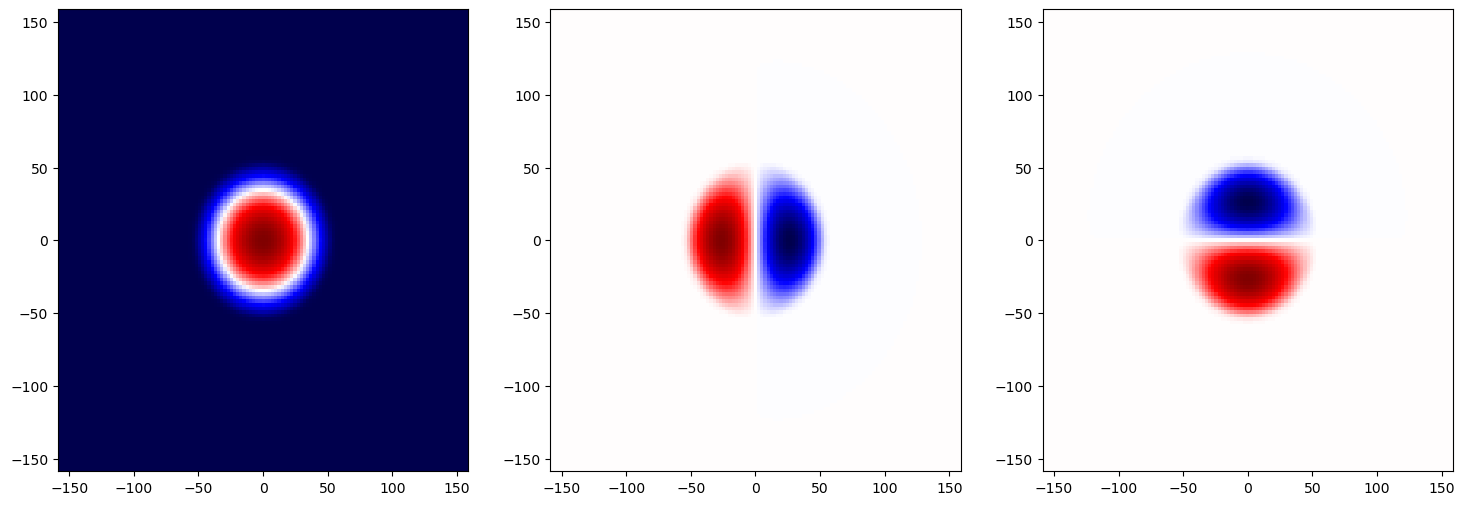

In [5]:
figure(figsize=(18,6))

for ii = 1:3
    subplot(1,3,ii)
    pcolormesh(x*1e6,y*1e6,modes[:,:,ii],cmap="seismic")
end
display(gcf())

We are ready to setup a forward solve. First we set up initial conditions.

In [6]:
peak_power = 100000;
pulse_fwhm = 0.2;

# pulse_tau = pulse_fwhm / (2*acosh(sqrt(2)));
# initial_field = zeros(Nt,num_modes,1);
# initial_field[:,1,1] .= sqrt(peak_power)*sech.(t/pulse_tau);

coefficient_vector = zeros(num_modes);
coefficient_vector[1] = 1.0;

initial_field = gaussian_pulse(
    domain, num_modes;
    peak_power=peak_power, # W
    fwhm=pulse_fwhm,
    coefficients = coefficient_vector
);

The code require us to collect all parameters as follows

In [7]:
parameters = MMGNLSEParameters(domain;
length=fiber_length,
beta=properties.beta,
S=properties.S,
n2=properties.n2,
omega0=properties.omega0,
raman=properties.raman)

MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}, Nothing}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, SpatialOverlap{Float64}, Float64, Float64, AnisotropicRaman{Float64}}(MMGNLSEDomain{TimeGrid{Float64}, Nothing}(DegreesOfFreedom(:time, :space), TimeGrid{Float64}(2048, 0.0048828125), nothing), 2.86, [0;;;;], [0;;;;], TaylorBeta{Float64, 2}([6.58743778344516e6 6.58721209206506e6 6.58721209206506e6; 4876.066183290184 4876.219784144979 4876.219784144979; … ; -2.557747949166768e-7 -2.569478135168283e-7 -2.569478135168283e-7; 1.0507874940407848e-9 1.0537998629535228e-9 1.0537998629535228e-9]), SpatialOverlap{Float64}([2.231855540561089e8 1.569614503826469e-8 -6.84912567983315e-10; 1.569614503826469e-8 1.526005657118049e8 -4.3504731793960416e-10; -6.84912567983315e-10 -4.3504731793960416e-10 1.5260056571180496e8;;; 1.569614503826469e-8 1.5260056571180487e8 -6.503342991754878e-10; 1.5260056571180487e8 -2.1167509937580604e-8 4.850871114857864e-10; -6.503342991754878e

Now we can solve.

In [8]:
dz = fiber_length/4000;
solution = solve_mmgnlse(initial_field, parameters, dz; saveat=0.1);

Visualizing the solution.

In [9]:
At_final = get_temporal_field(solution)
Aomega_final = get_spectral_field(solution)
z_saved = solution.z;

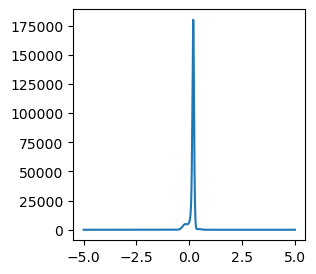

In [10]:
figure(figsize=(3,3))
plot(t,abs2.(At_final[:,1,1]))
display(gcf())

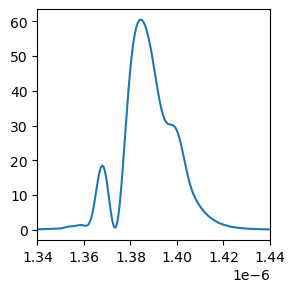

In [11]:
figure(figsize=(3,3))
plot(λ,abs2.(Aomega_final[:,1,1]))
xlim(1340e-9,1440e-9)
display(gcf())

## CP Decomposition

Let us now show that by compressing the four-wave mixing tensor in advance of the calculation, it can be sped up significantly. The added work to do this amounts to compressing the S-tensor and recreating the parameters to incorporate the compressed tensor.

In [12]:
S_compressed = cp_compress(properties.S,error=1e-3);

In [13]:
parameters_cp = MMGNLSEParameters(domain;
length=fiber_length,
beta=properties.beta,
S=S_compressed,
n2=properties.n2,
omega0=properties.omega0,
raman=properties.raman)

dz = 1e-3;

solution_cp = solve_mmgnlse(initial_field, parameters_cp, dz; saveat=0.1);

In [14]:
At_final_cp = get_temporal_field(solution_cp)
Aomega_final_cp = get_spectral_field(solution_cp)
z_saved_cp = solution_cp.z;

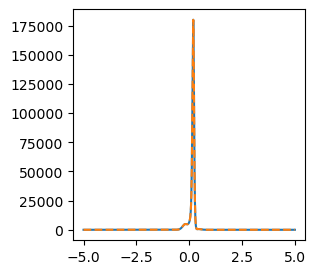

In [15]:
figure(figsize=(3,3))
plot(t,abs2.(At_final[:,1,1]))
plot(t,abs2.(At_final_cp[:,1,1]),"--")
display(gcf())

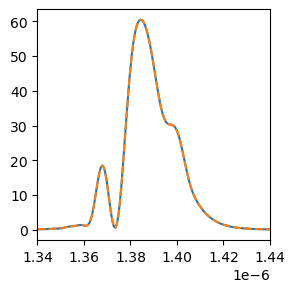

In [16]:
figure(figsize=(3,3))
plot(λ,abs2.(Aomega_final[:,1,1]))
plot(λ,abs2.(Aomega_final_cp[:,1,1]),"--")
xlim(1340e-9,1440e-9)
display(gcf())

At six modes, there is a speedup of around 10x. Now we look at the adjoint.

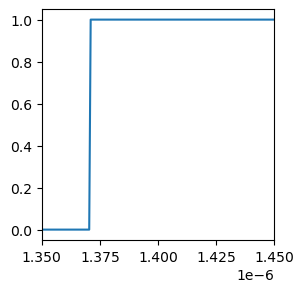

In [17]:
long_pass_ind = argmin(abs.(λ .-  1370.6998e-9))
filter = zeros(length(λ));
filter[1:long_pass_ind] .= 1.0;

figure(figsize=(3,3))
plot(λ, filter)
xlim(1350e-9,1450e-9)
display(gcf())

In [18]:
longpass_photon_number =  SpectralPhotonNumber(filter=filter, modes=:all);
filter_mean = value(longpass_photon_number, solution_cp)
lambda_L = terminal_condition(longpass_photon_number, solution_cp);

In [19]:
dz_adj = fiber_length/4000;

adjoint = solve_adjoint(lambda_L, parameters_cp, dz_adj; forward_solution=solution_cp);
# adjoint emits super verbose stuff now -- fix

MMGNLSEAdjointSolution{Float64, Array{ComplexF64, 4}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}, Nothing}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}, @NamedTuple{forward_solution::MMGNLSESolution{Float64, Array{ComplexF64, 4}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}, Nothing}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}, Array{ComplexF64, 3}, RK4IP, @NamedTuple{integration_z::Vector{Float64}, core::@NamedTuple{omega::Vector{Float64}, beta_operator::Array{ComplexF64, 3}, nonlinear_prefactor::Array{ComplexF64, 3}, nonlinear_active::Bool, raman::@NamedTuple{ha::Vector{ComplexF64}, hb::Vector{ComplexF64}, fraction::Float64}}, workspace::PulsePropagation.MMGNLSEScalarCPWorkspace{PulsePropagation.CPFastRHSCache{Float64, FFTW.cFFTWPlan{ComplexF64, -1,

In [20]:
filter_var = sum(abs2.(get_spectral_field(adjoint; units=:photon)[:,:,1]));

In [26]:
fano = filter_var / filter_mean
10log10(fano)

-7.679183368142483

We can check the adjoint against automatic differentiation: the agreement is very strong even for a coarse dz_ad (automatic differentiation is very memory intensive.)

In [22]:
dz_ad = 1e-2;
adjoint_ad = get_autodiff_adjoint(
    longpass_photon_number,
    initial_field,
    parameters_cp,
    dz_ad; units=:photon
)

2048×3×1 Array{ComplexF64, 3}:
[:, :, 1] =
 -9.12169e-12+3.2003e-12im   …   8.18578e-14-1.24973e-14im
  1.52679e-11+6.82915e-12im      -1.4224e-13-4.52295e-14im
 -6.56797e-12-7.28942e-12im      8.09077e-14-7.20665e-14im
  3.58936e-12+1.59534e-11im      1.68375e-13-1.12559e-13im
  1.35714e-11-2.01753e-11im     -2.07282e-13-2.41086e-13im
 -6.61464e-12+4.61196e-12im  …   -2.4387e-14+3.52992e-13im
   3.3392e-12+1.57456e-11im      9.78368e-14-2.83575e-14im
  1.52507e-11+1.61631e-12im      1.50197e-13-1.20228e-13im
 -3.05739e-13-2.45057e-11im      3.53929e-14+1.65671e-13im
 -1.33824e-11+3.64854e-12im      1.82384e-13-7.04223e-15im
             ⋮               ⋱  
 -2.43444e-11+2.22809e-11im      2.08692e-13+1.47421e-14im
  1.64272e-11+1.25062e-11im  …   2.43804e-13+9.19721e-14im
  1.87639e-12-4.43184e-11im     -3.15298e-13+3.57254e-13im
 -2.70966e-11+1.70988e-11im     -2.33358e-13-3.50947e-13im
    2.849e-11+2.58112e-11im     -1.99387e-13-2.67714e-13im
  2.15156e-11-9.78955e-12im     -1.5351

In [23]:
filter_var_ad = sum(abs2.(adjoint_ad))
fano_ad = 10log10.(filter_var_ad/filter_mean);

Let's benchmark this result against a stochastic (truncated Wigner) calculation. Without any key word arguments, a seed is set and the input noise is vacuum fluctuations in each mode (frequency-mode-polarization). See manual for details. 

In [24]:
num_ensemble = 100;
ensemble = solve_mmgnlse_stochastic(initial_field, parameters_cp, dz, num_ensemble)

MMGNLSEStochasticSolution{Float64, Array{ComplexF64, 5}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}, Nothing}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}, @NamedTuple{fano::Array{Float64, 3}, photon_noise::Array{ComplexF64, 4}, weights::Vector{Float64}, seed::Nothing}}([0.0, 2.86], ComplexF64[-0.0025031894739413474 + 0.0011140905839111925im 0.006326199006099249 - 0.0003350808923162879im 0.003351101852780175 + 0.002541769335973698im; 0.0017894206680182378 - 0.0037956405734300134im 0.0007279104455451821 - 0.0011375094511205741im -0.00044994156926901933 - 0.0008690481189126162im; … ; -0.0015235793056120883 + 0.0029268152219984246im 0.0044545793115114245 - 0.0061647657950032984im 0.004259071757968034 - 0.003946418220721961im; -0.0033002978736789146 - 0.005191862014337603im -0.001645533182654462 - 0.00075595381622693im 0.0006809989418548434 - 0.001341320662522392im;;;; 0.

In [27]:
fano_stochastic = 10log10(var(value(longpass_photon_number, ensemble)) / filter_mean)

-8.025779428697879